# Fase 6 — Despliegue: pipeline de inferencia

Prepara los artefactos del despliegue (SVM con probabilidades, umbrales de tamaño por fruta) y **demuestra** el pipeline de inferencia (segmentación + predicción de calidad + tamaño) sobre imágenes de muestra.

> La interfaz está en `app/streamlit_app.py`. Conclusiones en `reports/06_despliegue.md`.

## 0. Configuración

In [1]:
import sys, json, time
from pathlib import Path
root = Path.cwd()
while not (root/'src').exists() and root!=root.parent: root=root.parent
sys.path.insert(0, str(root))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from src.data.dataset import build_index, FRUITS, QUALITY_ORDER, QUALITY_PALETTE
from src.data import preprocess as pp
from src.utils.segmentation import segment_fruit, area_fraction, classify_size
sns.set_theme(style='whitegrid')
ART = root/'artifacts'
df = pp.clean_index(build_index())
print('Imágenes:', len(df))

Imágenes: 7803


## 1. SVM de despliegue (con probabilidades)

Se reentrena el SVM (mismos hiperparámetros) con `probability=True` para mostrar probabilidades por clase en la GUI.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
d = np.load(ART/'features.npz', allow_pickle=True); Xtr, ytr = d['Xtr'], d['ytr']
t0=time.time()
svm_d = Pipeline([('s',StandardScaler()), ('svc',SVC(kernel='rbf',C=10,gamma='scale',class_weight='balanced',probability=True,random_state=42))]).fit(Xtr,ytr)
joblib.dump(svm_d, ART/'svm_deploy.pkl')
print(f'SVM (probabilidades) entrenado y guardado en {time.time()-t0:.0f}s')

SVM (probabilidades) entrenado y guardado en 65s


## 2. Calibración de umbrales de tamaño (terciles por fruta)

Se segmenta cada imagen, se mide la fracción de área de la fruta y se calculan los percentiles 33 y 66 por tipo de fruta.

In [3]:
t0=time.time()
df['area_frac'] = [area_fraction(np.asarray(pp.load_rgb(p, size=(256,256)), dtype=np.uint8)) for p in df['path']]
print(f'Segmentación de {len(df)} imágenes en {time.time()-t0:.0f}s')

thresholds = {}
for fr in FRUITS:
    a = df[df.fruit==fr]['area_frac'].to_numpy()
    p33, p66 = np.percentile(a, [33, 66])
    thresholds[fr] = [float(p33), float(p66)]
thresholds['_global'] = [float(np.percentile(df['area_frac'],33)), float(np.percentile(df['area_frac'],66))]
json.dump(thresholds, open(ART/'size_thresholds.json','w'), indent=2)
print('Umbrales por fruta (p33, p66):')
display(pd.DataFrame(thresholds, index=['p33','p66']).T.round(3))

Segmentación de 7803 imágenes en 255s
Umbrales por fruta (p33, p66):


,p33,p66
Apple,0.331,0.529
Banana,0.222,0.352
Guava,0.246,0.398
Lime,0.280,0.378
Orange,0.371,0.534
Pomegranate,0.419,0.532
_global,0.332,0.497


## 3. Distribución del área relativa por fruta

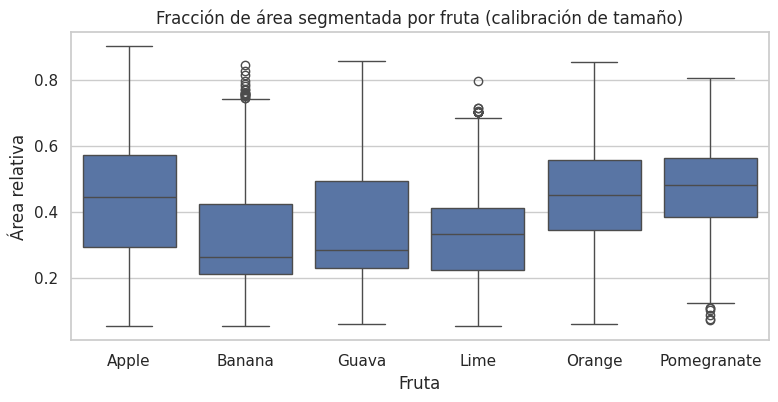

In [4]:
fig, ax = plt.subplots(figsize=(9,4))
sns.boxplot(data=df, x='fruit', y='area_frac', order=FRUITS, ax=ax)
ax.set_title('Fracción de área segmentada por fruta (calibración de tamaño)')
ax.set_xlabel('Fruta'); ax.set_ylabel('Área relativa')
plt.show()

## 4. Demostración del pipeline de inferencia

Para varias imágenes de muestra: segmentación + calidad (SVM y CNN) + tamaño.

/tmp/claude-1000/ipykernel_226776/3924751976.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('quality', group_keys=False).apply(lambda g: g.sample(1, random_state=7)).head(3)


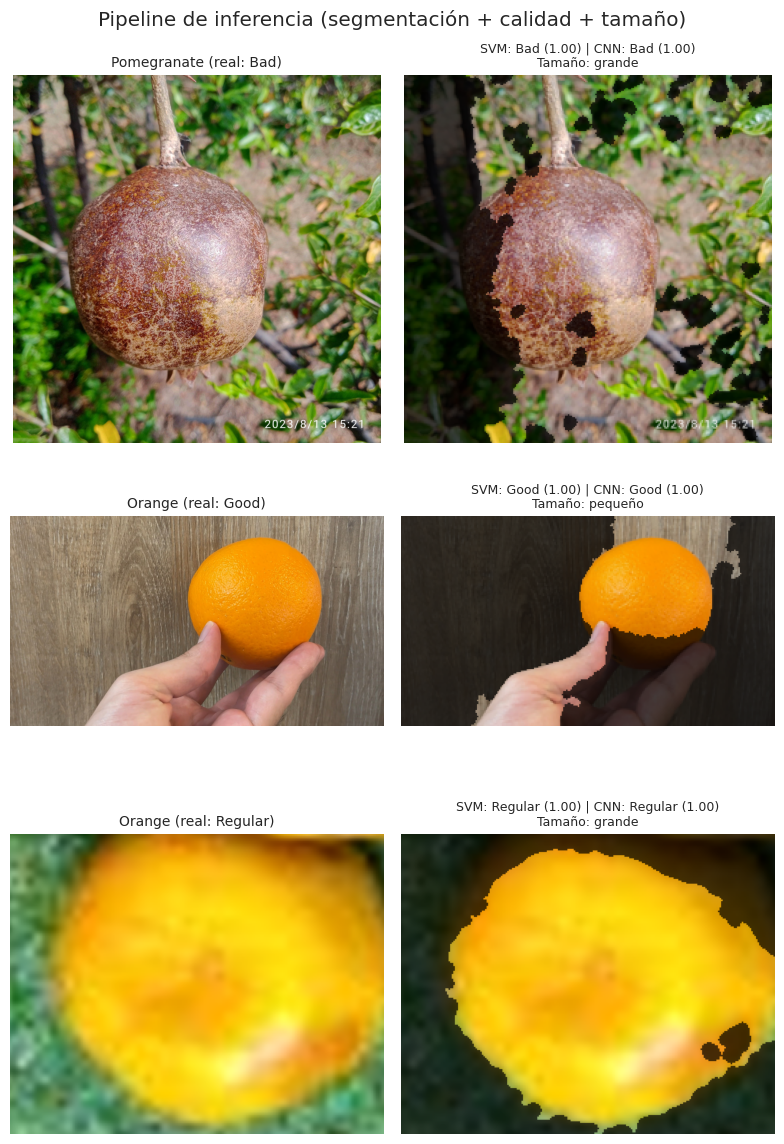

In [5]:
from src.deployment.predict import predict_quality, estimate_size
sample = df.groupby('quality', group_keys=False).apply(lambda g: g.sample(1, random_state=7)).head(3)
fig, axes = plt.subplots(len(sample), 2, figsize=(8, 4*len(sample)))
for r,(_,row) in enumerate(sample.iterrows()):
    rgb = np.asarray(pp.load_rgb(row['path']), dtype=np.uint8)
    q_svm = predict_quality(rgb, 'svm'); q_cnn = predict_quality(rgb, 'cnn')
    sz = estimate_size(rgb, row['fruit'])
    axes[r,0].imshow(rgb); axes[r,0].axis('off')
    axes[r,0].set_title(f"{row['fruit']} (real: {row['quality']})", fontsize=10)
    mask = sz['mask']; base = np.asarray(pp.load_rgb(row['path'], size=(mask.shape[1],mask.shape[0])))
    ov = base.copy(); ov[~mask]=(ov[~mask]*0.3).astype(np.uint8)
    axes[r,1].imshow(ov); axes[r,1].axis('off')
    psvm=max(q_svm,key=q_svm.get); pcnn=max(q_cnn,key=q_cnn.get)
    axes[r,1].set_title(f"SVM: {psvm} ({q_svm[psvm]:.2f}) | CNN: {pcnn} ({q_cnn[pcnn]:.2f})\nTamaño: {sz['size']}", fontsize=9)
plt.suptitle('Pipeline de inferencia (segmentación + calidad + tamaño)'); plt.tight_layout(); plt.show()